In [1]:
import kagglehub
import pandas as pd
import os

# Download dataset
path = kagglehub.dataset_download("janiobachmann/bank-marketing-dataset")

print("Dataset path:", path)
print("Files:", os.listdir(path))

df = pd.read_csv(f"{path}/bank.csv", sep=",")

df.head()

100%|██████████| 142k/142k [00:00<00:00, 20.4MB/s]

Extracting files...
Dataset path: /root/.cache/kagglehub/datasets/janiobachmann/bank-marketing-dataset/versions/1
Files: ['bank.csv']


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [2]:
print("Dataset Shape:", df.shape)

print("\nFeature Data Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Dataset Shape: (11162, 17)

Feature Data Types:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
deposit      object
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 

In [3]:
print("Target Distribution:")
print(df["deposit"].value_counts())

print("\nTarget Distribution (%):")
print(df["deposit"].value_counts(normalize=True) * 100)

Target Distribution:
deposit
no     5873
yes    5289
Name: count, dtype: int64

Target Distribution (%):
deposit
no     52.616019
yes    47.383981
Name: proportion, dtype: float64


In [4]:
print("Missing Values:")
print(df.isnull().sum())

print("\nNumber of Duplicate Rows:")
print(df.duplicated().sum())

Missing Values:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

Number of Duplicate Rows:
0


In [ ]:
#df = df.drop_duplicates()

#print("Dataset shape after removing duplicates:", df.shape)

In [5]:
# Features
X = df.drop("deposit", axis=1)

# Target
y = df["deposit"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (11162, 16)
y shape: (11162,)


In [6]:
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']

Categorical Features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [7]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30, # basicallly validation + testing is 30%
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Temporary (validation + testing) set:", X_temp.shape)

Training set: (7813, 16)
Temporary (validation + testing) set: (3349, 16)


In [8]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Test set:", X_test.shape)

Training set: (7813, 16)
Validation set: (1674, 16)
Test set: (1675, 16)


In [9]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nValidation target distribution:")
print(y_val.value_counts(normalize=True) * 100)

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training target distribution:
deposit
no     52.617432
yes    47.382568
Name: proportion, dtype: float64

Validation target distribution:
deposit
no     52.628435
yes    47.371565
Name: proportion, dtype: float64

Test target distribution:
deposit
no     52.597015
yes    47.402985
Name: proportion, dtype: float64


In [10]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# numerical preprocessing
numerical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")), #because median is more robust to outliers
    ("scaler", StandardScaler())
])

# categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# combine preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [11]:
X_train_processed = preprocessor.fit_transform(X_train)

X_val_processed = preprocessor.transform(X_val)
X_test_processed = preprocessor.transform(X_test)

print("Processed training shape:", X_train_processed.shape)
print("Processed validation shape:", X_val_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed training shape: (7813, 51)
Processed validation shape: (1674, 51)
Processed test shape: (1675, 51)


### FEATURE ENGINEERING DECISIONS:

1. Target:
   - 'y' is the target variable.
   - It represents a classification problem: yes/no.

2. Duplicates:
   - Duplicate rows were removed to avoid repeated observations
     having extra influence on the model.

3. Missing Values:
   - Numerical features: median imputation.
   - Categorical features: most frequent value imputation.

4. Categorical Features:
   - One-Hot Encoding was used.
   - handle_unknown='ignore' prevents errors if new categories
     appear in validation or test data.

5. Numerical Features:
   - StandardScaler was applied.
   - Scaling is useful for algorithms dependent on feature magnitude
     or distance, such as Logistic Regression, kNN, and SVM.

6. Data Splitting:
   - 70% training, 15% validation, and 15% test.
   - random_state=42 ensures reproducible results.
   - Stratification was used because the target classes are imbalanced.

7. Data Leakage Prevention:
   - The preprocessing pipeline was fitted only on the training data.
   - Validation and test sets were transformed using the training-fitted pipeline.

In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# shallowtree
shallow_dt = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

# deeper tree
deep_dt = DecisionTreeClassifier(
    max_depth=8,
    random_state=42
)

shallow_dt.fit(X_train_processed, y_train)
deep_dt.fit(X_train_processed, y_train)

print("both decision tree models trained")

both decision tree models trained


In [13]:
y_train_pred_shallow = shallow_dt.predict(X_train_processed)
y_train_pred_deep = deep_dt.predict(X_train_processed)

y_val_pred_shallow = shallow_dt.predict(X_val_processed)
y_val_pred_deep = deep_dt.predict(X_val_processed)

shallow_train_acc = accuracy_score(y_train, y_train_pred_shallow)
shallow_val_acc = accuracy_score(y_val, y_val_pred_shallow)

deep_train_acc = accuracy_score(y_train, y_train_pred_deep)
deep_val_acc = accuracy_score(y_val, y_val_pred_deep)

print("shallow tree (depth=3)")
print(f"Training Accuracy: {shallow_train_acc:.4f}")
print(f"Validation Accuracy: {shallow_val_acc:.4f}")

print("\ndeeper tree (depth=8)")
print(f"Training Accuracy: {deep_train_acc:.4f}")
print(f"Validation Accuracy: {deep_val_acc:.4f}")

shallow tree (depth=3)
Training Accuracy: 0.7756
Validation Accuracy: 0.7879

deeper tree (depth=8)
Training Accuracy: 0.8506
Validation Accuracy: 0.8309


so deeper tree is better as it has higher validation accuracy

In [14]:
best_dt = deep_dt
best_depth = 8

print(f"Selected Decision Tree: max_depth = {best_depth}")

Selected Decision Tree: max_depth = 8


In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_val_pred = best_dt.predict(X_val_processed)

accuracy_dt = accuracy_score(y_val, y_val_pred)
precision_dt = precision_score(y_val, y_val_pred, pos_label="yes")
recall_dt = recall_score(y_val, y_val_pred, pos_label="yes")
f1_dt = f1_score(y_val, y_val_pred, pos_label="yes")

print("for dt with depth 8")
print(f"Accuracy: {accuracy_dt:.4f}")
print(f"Precision: {precision_dt:.4f}")
print(f"Recall: {recall_dt:.4f}")
print(f"F1-score: {f1_dt:.4f}")

for dt with depth 8
Accuracy: 0.8309
Precision: 0.8117
Recall: 0.8373
F1-score: 0.8243


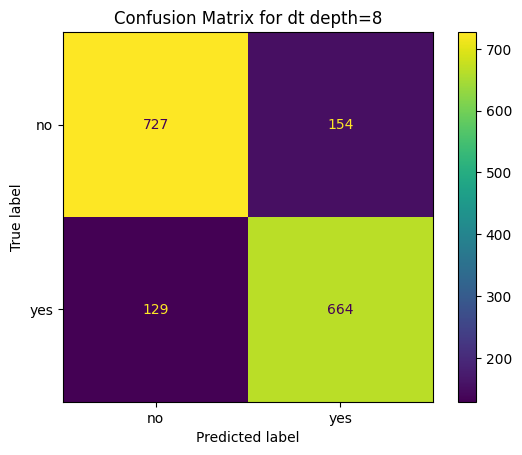

In [16]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred)

plt.title("Confusion Matrix for dt depth=8")
plt.show()

Validation ROC-AUC: 0.8744


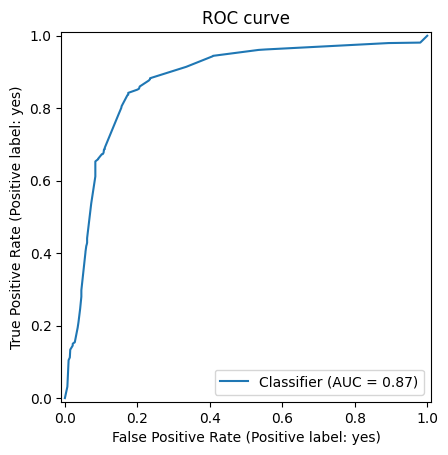

In [17]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay
y_val_prob_dt = best_dt.predict_proba(X_val_processed)[:, 1]
roc_auc_dt = roc_auc_score(y_val, y_val_prob_dt)

print(f"Validation ROC-AUC: {roc_auc_dt:.4f}")

RocCurveDisplay.from_predictions(
    y_val,
    y_val_prob_dt,
    pos_label="yes"
)

plt.title("ROC curve")
plt.show()

In [18]:
import time

best_dt = DecisionTreeClassifier(
    max_depth=8,
    random_state=42
)

start_time = time.perf_counter()

best_dt.fit(X_train_processed, y_train)

training_time_dt = time.perf_counter() - start_time

print(f"Training Time: {training_time_dt:.6f} seconds")

Training Time: 0.062754 seconds


In [19]:
start_time = time.perf_counter()

y_val_pred = best_dt.predict(X_val_processed)

prediction_time_dt = time.perf_counter() - start_time

print(f"prediction time: {prediction_time_dt:.6f} seconds")
print(
    f"Avg prediction Time per sample: "
    f"{prediction_time_dt / len(X_val):.8f} seconds"
)

prediction time: 0.001625 seconds
Avg prediction Time per sample: 0.00000097 seconds


In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

rf.fit(X_train_processed, y_train)

print("random forest model training done!!")

random forest model training done!!


In [21]:
from sklearn.metrics import accuracy_score

y_train_pred_rf = rf.predict(X_train_processed)
y_val_pred_rf = rf.predict(X_val_processed)

train_accuracy_rf = accuracy_score(y_train, y_train_pred_rf)
val_accuracy_rf = accuracy_score(y_val, y_val_pred_rf)

print(f"training accuracy: {train_accuracy_rf:.4f}")
print(f"validation accuracy: {val_accuracy_rf:.4f}")

training accuracy: 1.0000
validation accuracy: 0.8644


In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score

accuracy_rf = accuracy_score(y_val, y_val_pred_rf)

precision_rf = precision_score(
    y_val,
    y_val_pred_rf,
    pos_label="yes"
)

recall_rf = recall_score(
    y_val,
    y_val_pred_rf,
    pos_label="yes"
)

f1_rf = f1_score(
    y_val,
    y_val_pred_rf,
    pos_label="yes"
)

print("Random forest metrics")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"recall: {recall_rf:.4f}")
print(f"F1 score: {f1_rf:.4f}")

Random forest metrics
Accuracy: 0.8644
Precision: 0.8369
recall: 0.8865
F1 score: 0.8610


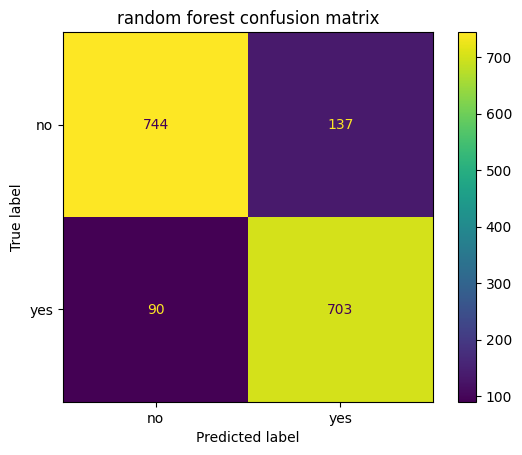

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred_rf
)

plt.title("random forest confusion matrix")
plt.show()

Validation ROC AUC: 0.9272


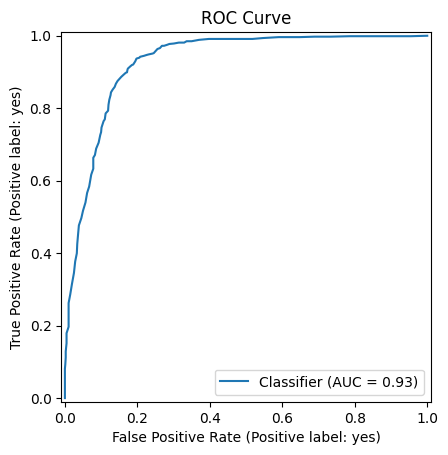

In [24]:
from sklearn.metrics import roc_auc_score, RocCurveDisplay

y_val_prob_rf = rf.predict_proba(X_val_processed)[:, 1]
roc_auc_rf = roc_auc_score(y_val, y_val_prob_rf)

print(f"Validation ROC AUC: {roc_auc_rf:.4f}")

RocCurveDisplay.from_predictions(
    y_val,
    y_val_prob_rf,
    pos_label="yes"
)

plt.title("ROC Curve")
plt.show()

In [25]:
import time
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)

start_time = time.perf_counter()

rf.fit(X_train_processed, y_train)

training_time_rf = time.perf_counter() - start_time

print(f"training time: {training_time_rf:.6f} secs")

training time: 1.328863 secs


In [27]:
start_time = time.perf_counter()

y_val_pred_rf = rf.predict(X_val_processed)

prediction_time_rf = time.perf_counter() - start_time

print(f"Prediction Time: {prediction_time_rf:.6f} secs")


Prediction Time: 0.250168 secs
